# Experimento 03 - benchmark visual por janela

Notebook para comparar a acuracia dos modelos nas temporadas mais recentes do experimento 03.

- Temporadas: `2021-2022`, `2022-2023`, `2023-2024`
- Uma celula de grafico para cada janela: `5`, `10` e `15`
- Foco atual: acuracia


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'results' / 'experimento_03').exists():
            return candidate
    raise FileNotFoundError(
        'Nao foi possivel localizar a raiz do projeto com a pasta results/experimento_03.'
    )


BASE_DIR = find_project_root(Path.cwd())
RESULTS_DIR = BASE_DIR / 'results' / 'experimento_03'
SEASONS = ['2021-2022', '2022-2023', '2023-2024']

MODEL_SPECS = {
    'SVM': {
        'file_template': 'svm_experimento_03_janela{window}.csv',
        'color': '#4C72B0',
    },
    'KNN': {
        'file_template': 'knn_experimento_03_janela{window}.csv',
        'color': '#DD8452',
    },
    'Extra Trees': {
        'file_template': 'extra_trees_experimento_03_janela{window}.csv',
        'color': '#55A868',
    },
    'Regressao Logistica': {
        'file_template': 'regressao_logistica_experimento_03_janela{window}.csv',
        'color': '#C44E52',
    },
    'LightGBM': {
        'file_template': 'lightgbm_experimento_03_janela{window}.csv',
        'color': '#8172B2',
    },
}


def find_accuracy_column(columns):
    for column in columns:
        normalized = str(column).lower()
        if 'cur' in normalized or 'acc' in normalized:
            return column
    raise KeyError('Coluna de acuracia nao encontrada.')


def load_window_results(window):
    rows = []
    missing_models = []

    for model_name, spec in MODEL_SPECS.items():
        file_path = RESULTS_DIR / spec['file_template'].format(window=window)

        if not file_path.exists():
            missing_models.append(model_name)
            continue

        df = pd.read_csv(file_path)
        accuracy_column = find_accuracy_column(df.columns)

        filtered = df[df['Temporada'].astype(str).isin(SEASONS)].copy()

        if filtered.empty:
            continue

        filtered['Modelo'] = model_name
        filtered['Acuracia'] = filtered[accuracy_column].astype(float)
        rows.append(filtered[['Temporada', 'Modelo', 'Acuracia']])

    if rows:
        result = pd.concat(rows, ignore_index=True)
        result['Temporada'] = pd.Categorical(result['Temporada'], categories=SEASONS, ordered=True)
        result = result.sort_values(['Temporada', 'Modelo'])
    else:
        result = pd.DataFrame(columns=['Temporada', 'Modelo', 'Acuracia'])

    return result, missing_models


def plot_window(window):
    df, missing_models = load_window_results(window)

    if df.empty:
        raise ValueError(f'Nenhum resultado encontrado para a janela {window}. RESULTS_DIR = {RESULTS_DIR}')

    pivot = df.pivot(index='Temporada', columns='Modelo', values='Acuracia').reindex(SEASONS)
    available_models = [model for model in MODEL_SPECS if model in pivot.columns]
    colors = [MODEL_SPECS[model]['color'] for model in available_models]

    ax = pivot[available_models].plot(
        kind='bar',
        figsize=(12, 6),
        color=colors,
        width=0.82,
        edgecolor='white'
    )

    ax.set_title(f'Experimento 03 - Acuracia por modelo | Janela = {window}', fontsize=14, pad=14)
    ax.set_xlabel('Temporada')
    ax.set_ylabel('Acuracia')
    ax.set_ylim(0.50, 0.85)
    ax.legend(title='Modelos', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.set_axisbelow(True)
    plt.xticks(rotation=0)

    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append(f'{height:.3f}' if not np.isnan(height) else '')
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)

    if missing_models:
        missing_text = 'Arquivos ausentes nesta janela: ' + ', '.join(missing_models)
        ax.text(
            0.01,
            0.98,
            missing_text,
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=9,
            color='#8B0000',
            bbox={'facecolor': '#FFF3F3', 'edgecolor': '#D9A3A3', 'boxstyle': 'round,pad=0.3'}
        )

    plt.tight_layout()
    plt.show()

    display(pivot[available_models].style.format('{:.4f}'))

    return pivot


print(f'BASE_DIR: {BASE_DIR}')
print(f'RESULTS_DIR: {RESULTS_DIR}')
display(pd.DataFrame({'Temporadas selecionadas': SEASONS}))


BASE_DIR: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction
RESULTS_DIR: c:\Users\Pedro conrado\Documents\stack-ensemble-prediction\results\experimento_03


,Temporadas selecionadas
0,2021-2022
1,2022-2023
2,2023-2024


In [ ]:
plot_window(5)


: 

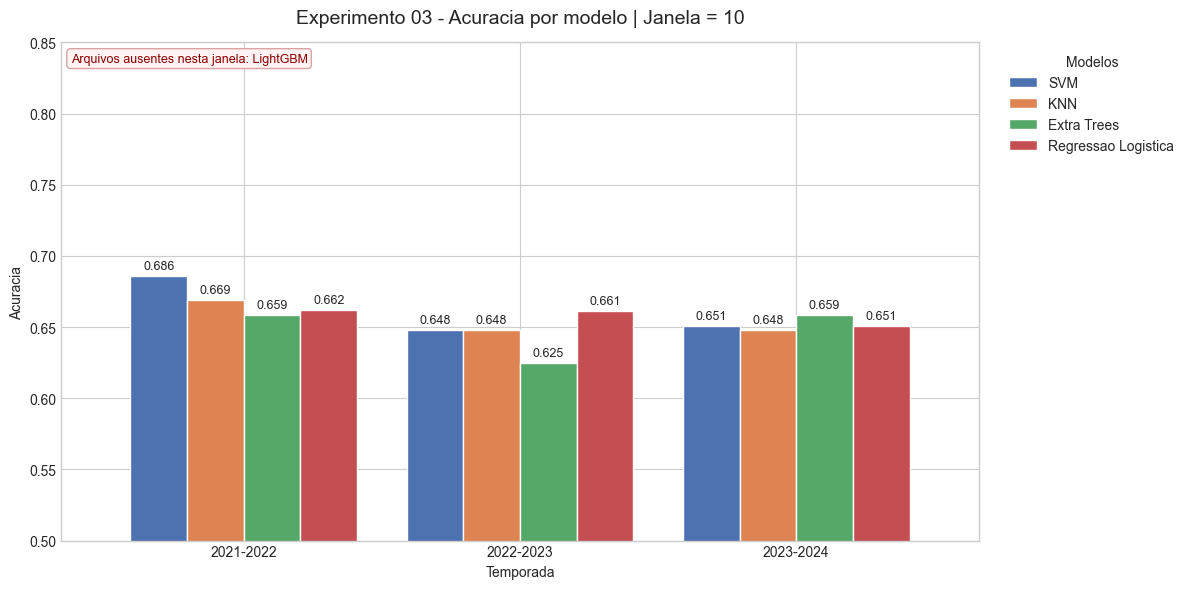

AttributeError: The '.style' accessor requires jinja2

In [28]:
plot_window(10)


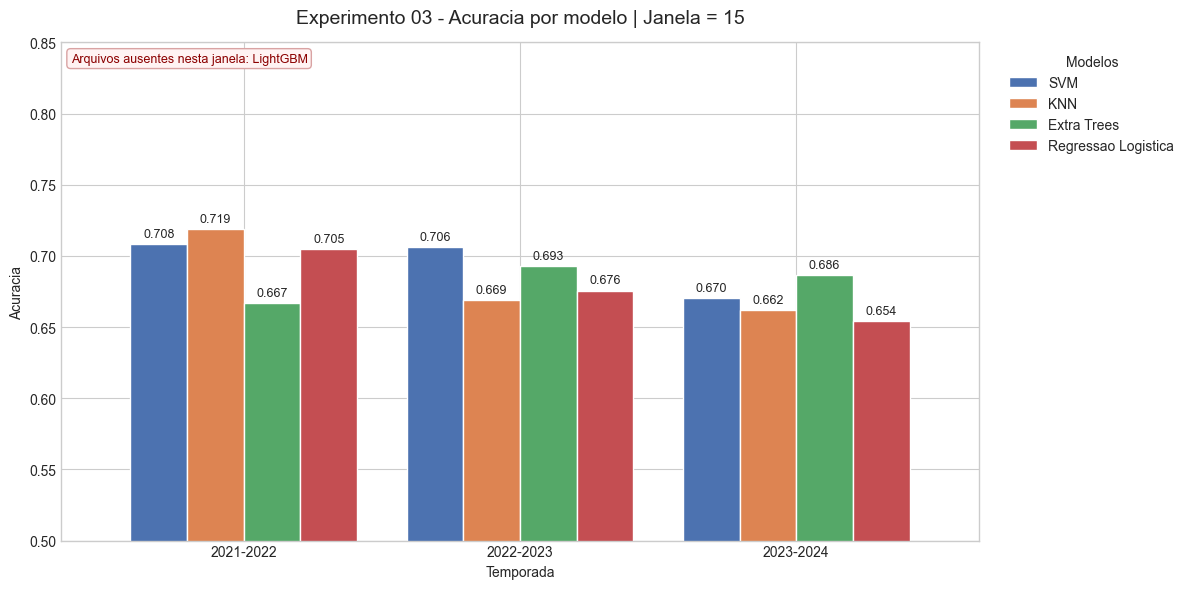

AttributeError: The '.style' accessor requires jinja2

In [29]:
plot_window(15)
